# Habitat Headless Test

Quick verification that habitat-sim + habitat-lab work in the uv env.

**Kernel:** uv-managed Python (`uv run jupyter lab`)

---
## 1. Import Checks

In [1]:
import os
from pathlib import Path

# Ensure CWD is the project root (parent of notebooks/)
project_root = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
os.chdir(project_root)
print(f"Working directory: {Path.cwd()}")

Working directory: /pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA


In [2]:
import sys
print(f"Python: {sys.version}")

import habitat_sim
print(f"habitat-sim: {habitat_sim.__version__}")

import habitat
print(f"habitat-lab: {habitat.__version__}")

import numpy as np
import matplotlib.pyplot as plt
print("Core imports OK")

Python: 3.13.3 (main, Apr  9 2025, 04:03:52) [Clang 20.1.0 ]


/pfs/data6/home/ul/ul_student/ul_hfj15/Master-Thesis-3D-VLA/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


habitat-sim: 0.3.3


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


habitat-lab: 0.3.3


Core imports OK


---
## 2. Test Scene Load + RGB-D Rendering

Renderer: NVIDIA H100/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.195.03
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-broken-buffer-dsa
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-framebuffer-invalidation-wants-draw-binding
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-

color_sensor: (256, 256, 4) uint8
depth_sensor: (256, 256) float32


[14:00:45:817335]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'default' : Lighting Layout Attributes 'no_lights' specified in Scene Attributes but does not exist in dataset, so creating default.
[14:00:45:817998]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `data/scene_datasets/habitat-test-scenes/skokloster-castle.scn` does not exist.  Aborting load.
[14:00:45:818043]:[Warning]:[Scene] SemanticScene.cpp(124)::loadSemanticSceneDescriptor : SSD File Naming Issue! Neither SemanticAttributes-provided name : `data/scene_datasets/habitat-test-scenes/skokloster-castle.scn` nor constructed filename : `data/scene_datasets/habitat-test-scenes/info_semantic.json` exist on disk.
[14:00:45:818058]:[Error]:[Scene] SemanticScene.cpp(140)::loadSemanticSceneDescriptor : SSD Load Failure! File with SemanticAttributes-provided name `data/scene_datasets/habitat-test-scenes/skokloster-castle.scn` exists but

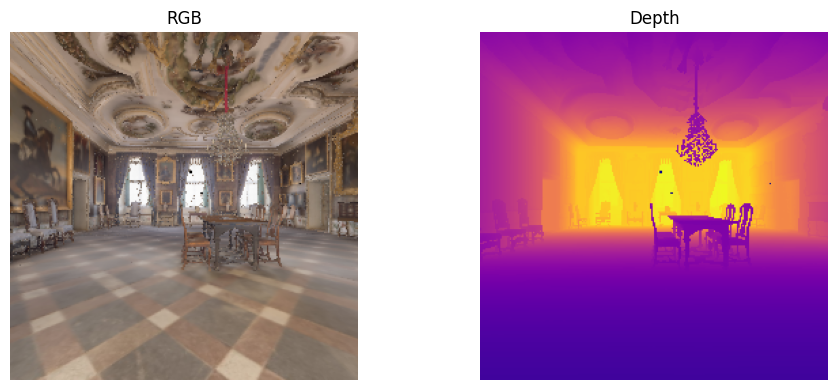

In [3]:
import habitat_sim
import numpy as np
import matplotlib.pyplot as plt

cfg = habitat_sim.SimulatorConfiguration()
cfg.scene_id = "data/scene_datasets/habitat-test-scenes/skokloster-castle.glb"

# RGB sensor
rgb_spec = habitat_sim.CameraSensorSpec()
rgb_spec.uuid = "color_sensor"
rgb_spec.sensor_type = habitat_sim.SensorType.COLOR
rgb_spec.resolution = [256, 256]

# Depth sensor
depth_spec = habitat_sim.CameraSensorSpec()
depth_spec.uuid = "depth_sensor"
depth_spec.sensor_type = habitat_sim.SensorType.DEPTH
depth_spec.resolution = [256, 256]

agent_cfg = habitat_sim.agent.AgentConfiguration()
agent_cfg.sensor_specifications = [rgb_spec, depth_spec]

sim = habitat_sim.Simulator(habitat_sim.Configuration(cfg, [agent_cfg]))
obs = sim.get_sensor_observations()

print(f"color_sensor: {obs['color_sensor'].shape} {obs['color_sensor'].dtype}")
print(f"depth_sensor: {obs['depth_sensor'].shape} {obs['depth_sensor'].dtype}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(obs["color_sensor"][:, :, :3])
axes[0].set_title("RGB")
axes[0].axis("off")
axes[1].imshow(obs["depth_sensor"], cmap="plasma")
axes[1].set_title("Depth")
axes[1].axis("off")
plt.tight_layout()
plt.show()

---
## 3. Basic Navigation Loop

Available actions: ['move_forward', 'turn_left', 'turn_right']


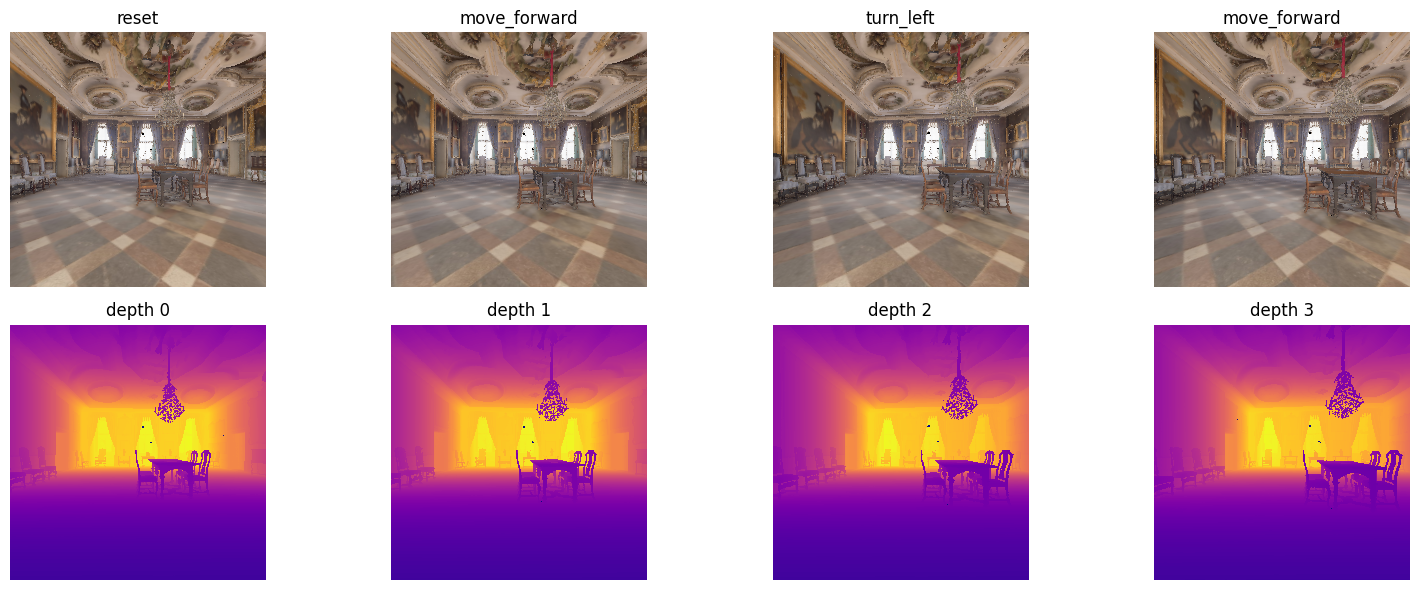

Final position: [-1.8795687  0.1523323 18.262844 ]
Final rotation: quaternion(1, 0, 2.45869159698486e-05, 0)
Sim closed.


In [4]:
agent = sim.get_agent(0)
action_names = list(agent.agent_config.action_space.keys())
print(f"Available actions: {action_names}")

# Execute a sequence of actions
action_seq = ["move_forward", "turn_left", "move_forward", "move_forward", "turn_right", "move_forward"]
frames = [obs]

for action in action_seq:
    obs = sim.step(action)
    frames.append(obs)

# Visualize first 4 frames
n_show = min(4, len(frames))
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 6))
labels = ["reset"] + action_seq
for i in range(n_show):
    axes[0, i].imshow(frames[i]["color_sensor"][:, :, :3])
    axes[0, i].set_title(labels[i])
    axes[0, i].axis("off")
    axes[1, i].imshow(frames[i]["depth_sensor"], cmap="plasma")
    axes[1, i].set_title(f"depth {i}")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

state = agent.get_state()
print(f"Final position: {state.position}")
print(f"Final rotation: {state.rotation}")

sim.close()
print("Sim closed.")

---
## 4. ObjectNav Episode Load (val_mini)

Requires HM3D scene files (Matterport token). If scenes unavailable, loads episode metadata only.

In [5]:
import json, gzip
from pathlib import Path

DATA_DIR = Path("data/datasets/objectnav/hm3d/objectnav_hm3d_v2")
SCENE_DIR = Path("data/scene_datasets/hm3d")

# Load val_mini episodes
content_dir = DATA_DIR / "val_mini" / "content"
if content_dir.exists():
    content_files = sorted(content_dir.glob("*.json.gz"))
    episodes = []
    for cf in content_files:
        with gzip.open(cf, "rt") as f:
            data = json.load(f)
        episodes.extend(data.get("episodes", []))
    print(f"Loaded {len(episodes)} val_mini episodes from {len(content_files)} scene files")

    ep = episodes[0]
    print(f"\nFirst episode:")
    print(f"  scene_id: {ep['scene_id']}")
    print(f"  target: {ep['object_category']}")
    print(f"  geodesic_distance: {ep['info']['geodesic_distance']:.2f} m")

    # Check if scene files exist
    has_scenes = SCENE_DIR.exists() and any(SCENE_DIR.rglob("*.glb"))
    print(f"\nHM3D scene files available: {has_scenes}")
else:
    print(f"Episode data not found at {content_dir}")
    print("Run: download ObjectNav episodes first (see habitat_objectnav_benchmark.ipynb)")

Loaded 30 val_mini episodes from 2 scene files

First episode:
  scene_id: hm3d_v0.2/minival/00800-TEEsavR23oF/TEEsavR23oF.basis.glb
  target: bed
  geodesic_distance: 5.41 m

HM3D scene files available: True


---
## 5. Single ObjectNav Step (with HM3D scenes)

This cell only runs if HM3D scene files are downloaded.

2026-03-11 14:00:47,487 Initializing dataset ObjectNav-v1


2026-03-11 14:00:47,520 initializing sim Sim-v0


[14:00:47:533097]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'hm3d_annotated_basis' : Lighting Layout Attributes 'no_lights' specified in Scene Attributes but does not exist in dataset, so creating default.


2026-03-11 14:00:48,800 Initializing task ObjectNav-v1


[14:00:47:535023]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `data/scene_datasets/hm3d_v0.2/minival/00802-wcojb4TFT35/wcojb4TFT35.basis.scn` does not exist.  Aborting load.
[14:00:47:535180]:[Warning]:[Scene] SemanticScene.cpp(124)::loadSemanticSceneDescriptor : SSD File Naming Issue! Neither SemanticAttributes-provided name : `data/scene_datasets/hm3d_v0.2/minival/00802-wcojb4TFT35/wcojb4TFT35.basis.scn` nor constructed filename : `data/scene_datasets/hm3d_v0.2/minival/00802-wcojb4TFT35/info_semantic.json` exist on disk.
[14:00:47:535194]:[Error]:[Scene] SemanticScene.cpp(140)::loadSemanticSceneDescriptor : SSD Load Failure! File with SemanticAttributes-provided name `data/scene_datasets/hm3d_v0.2/minival/00802-wcojb4TFT35/wcojb4TFT35.basis.scn` exists but failed to load.
[14:00:48:664617]:[Warning]:[Sim] Simulator.cpp(595)::instanceStageForSceneAttributes : The active scene does not contain semantic annotations : activeSemanticSceneI

Renderer: NVIDIA H100/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 570.195.03
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-broken-buffer-dsa
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-framebuffer-invalidation-wants-draw-binding
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-

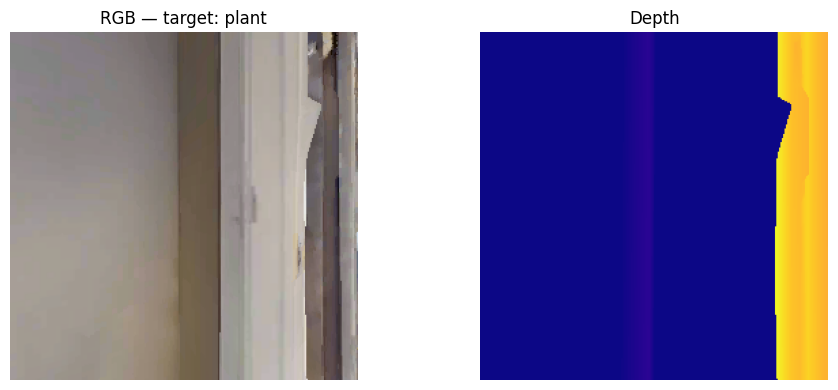

Environment closed.


In [6]:
from pathlib import Path

SCENE_DIR = Path("data/scene_datasets/hm3d")
DATA_DIR = Path("data/datasets/objectnav/hm3d/objectnav_hm3d_v2")
has_scenes = SCENE_DIR.exists() and any(SCENE_DIR.rglob("*.glb"))

if has_scenes:
    from habitat.config import read_write

    config = habitat.get_config(
        config_path="benchmark/nav/objectnav/objectnav_hm3d.yaml"
    )
    with read_write(config):
        config.habitat.dataset.split = "val_mini"
        config.habitat.dataset.data_path = str(
            DATA_DIR / "{split}" / "{split}.json.gz"
        )
        config.habitat.dataset.scenes_dir = "data/scene_datasets"
        # Point to the HM3D scene dataset config
        scene_cfg = next(SCENE_DIR.rglob("*scene_dataset_config.json"), None)
        if scene_cfg:
            config.habitat.simulator.scene_dataset = str(scene_cfg)
        agent_cfg = config.habitat.simulator.agents.main_agent
        for sensor in ["rgb_sensor", "depth_sensor"]:
            s = getattr(agent_cfg.sim_sensors, sensor)
            s.width = 256
            s.height = 256

    env = habitat.Env(config=config)
    obs = env.reset()
    print(f"Episode: {env.current_episode.episode_id}")
    print(f"Scene:   {env.current_episode.scene_id}")
    print(f"Target:  {env.current_episode.object_category}")
    print(f"Obs keys: {list(obs.keys())}")
    for k, v in obs.items():
        if hasattr(v, 'shape'):
            print(f"  {k}: {v.shape} {v.dtype}")

    # Take one step forward
    obs = env.step(action=1)  # MOVE_FORWARD

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(obs["rgb"])
    axes[0].set_title(f"RGB — target: {env.current_episode.object_category}")
    axes[0].axis("off")
    axes[1].imshow(obs["depth"].squeeze(), cmap="plasma")
    axes[1].set_title("Depth")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

    env.close()
    print("Environment closed.")
else:
    print("HM3D scenes not downloaded — skipping ObjectNav env test.")
    print("Download with:")
    print("  uv run python -m habitat_sim.utils.datasets_download \\")
    print("    --username <TOKEN_ID> --password <TOKEN_SECRET> \\")
    print("    --uids hm3d_minival_v0.2 --data-path data/")